# Разведочный анализ данных. Исследование и визуализация данных.
### 1) Текстовое описание набора данных
В качестве набора данных мы будем использовать датасет о данных о продажах мобильных устройств - https://www.kaggle.com/datasets/syedaeman2212/mobile-sales-data
Набор данных Mobile Sales Data — это синтетический набор данных, предназначенный для имитации реальных продаж смартфонов различных марок, регионов и временных периодов. Он подходит для анализа данных, визуализации, бизнес-аналитики и проектов машинного обучения.

Этот набор данных помогает анализировать показатели продаж, тенденции выручки, предпочтения клиентов и поведение рынка в мобильной индустрии.

### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

### Загрузка данных
Загрузим файлы датасета в помощью библиотеки Pandas.

In [2]:
data = pd.read_csv('synthetic_mobile_sales_2025.csv')

### 2) Основные характеристики датасета

In [3]:
# Первые 5 строк датасета
data.head()

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025


In [4]:
# Размер датасета - 500 строк, 13 колонок
data.shape

(500, 13)

In [5]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 500


In [6]:
# Список колонок
data.columns

Index(['Sale_ID', 'Brand', 'Model', 'Country', 'Storage', 'Color', 'Price_USD',
       'Units_Sold', 'Revenue_USD', 'Customer_Rating', 'Payment_Method',
       'Sale_Month', 'Sale_Year'],
      dtype='str')

In [7]:
# Список колонок с типами данных
data.dtypes

Sale_ID              int64
Brand                  str
Model                  str
Country                str
Storage                str
Color                  str
Price_USD            int64
Units_Sold           int64
Revenue_USD          int64
Customer_Rating    float64
Payment_Method         str
Sale_Month           int64
Sale_Year            int64
dtype: object

In [8]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений 0 - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{}-{}'.format(col, temp_null_count))

Sale_ID-0
Brand-0
Model-0
Country-0
Storage-0
Color-0
Price_USD-0
Units_Sold-0
Revenue_USD-0
Customer_Rating-0
Payment_Method-0
Sale_Month-0
Sale_Year-0


In [9]:
# Основные статистические характеристки набора данных
data.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Sale_Month,Sale_Year
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.0
mean,250.500000,889.88400,10.458000,9279.282000,4.022600,6.588000,2025.0
std,144.481833,345.61789,5.710118,6474.699423,0.582329,3.414905,0.0
min,1.000000,302.00000,1.000000,302.000000,3.000000,1.000000,2025.0
25%,125.750000,572.00000,6.000000,3959.250000,3.575000,4.000000,2025.0
50%,250.500000,896.50000,10.000000,8086.500000,4.000000,7.000000,2025.0
75%,375.250000,1173.75000,15.000000,13331.250000,4.500000,10.000000,2025.0
max,500.000000,1500.00000,20.000000,29660.000000,5.000000,12.000000,2025.0


In [10]:
# Определим уникальные значения для целевого признака
data['Customer_Rating'].unique()

array([3.7, 3.1, 3.6, 4.4, 3.8, 3.2, 4.2, 3.5, 4.8, 3.3, 4.1, 3.9, 4.6,
       4.5, 3.4, 3. , 4.7, 4. , 5. , 4.9, 4.3])

Целевой признак Customer_Rating является числовым и принимает значения от 1 до 5.

### 3) Визуальное исследование датасета
Для визуального исследования могут быть использованы различные виды диаграмм, мы построим только некоторые варианты диаграмм, которые используются достаточно часто.

### Диаграмма рассеяния
Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='Price_USD', ylabel='Revenue_USD'>

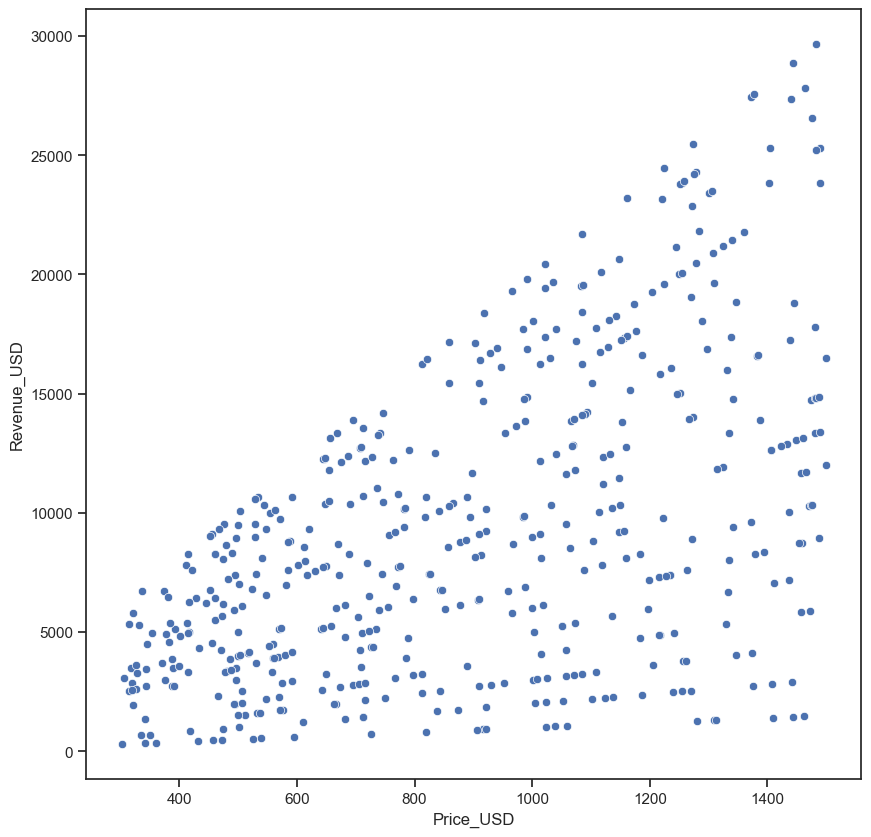

In [11]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Price_USD', y='Revenue_USD', data=data)

Между Price_USD и Revenue_USD наблюдается положительная зависимость — 
с ростом цены выручка в целом увеличивается. Однако значительный разброс 
точек указывает на то, что выручка определяется не только ценой, 
но и количеством проданных единиц.
Посмотрим, насколько на эту зависимость влияет целевой признак.

<Axes: xlabel='Price_USD', ylabel='Revenue_USD'>

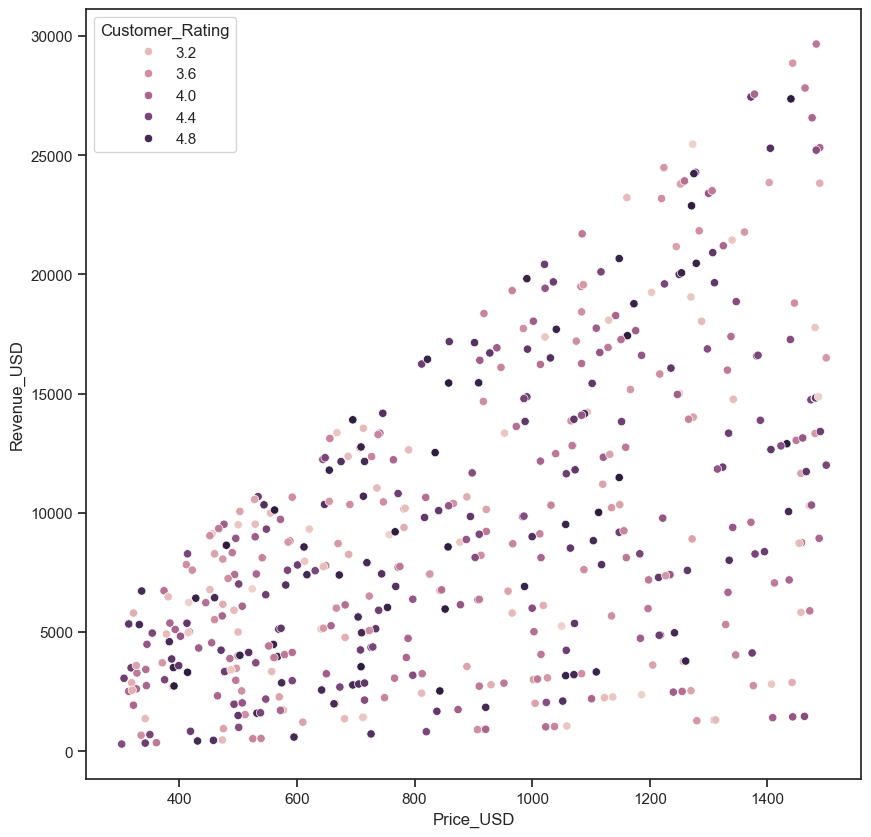

In [12]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Price_USD', y='Revenue_USD', data=data, hue='Customer_Rating')

Раскраска точек по Customer_Rating показывает, что рейтинг покупателя 
равномерно распределён по всем диапазонам цены и выручки — 
зависимости между этими признаками и целевым не обнаружено.

### Гистограмма

C:\Users\zagid\AppData\Local\Temp\ipykernel_26496\2878392692.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Customer_Rating'])


<Axes: xlabel='Customer_Rating', ylabel='Density'>

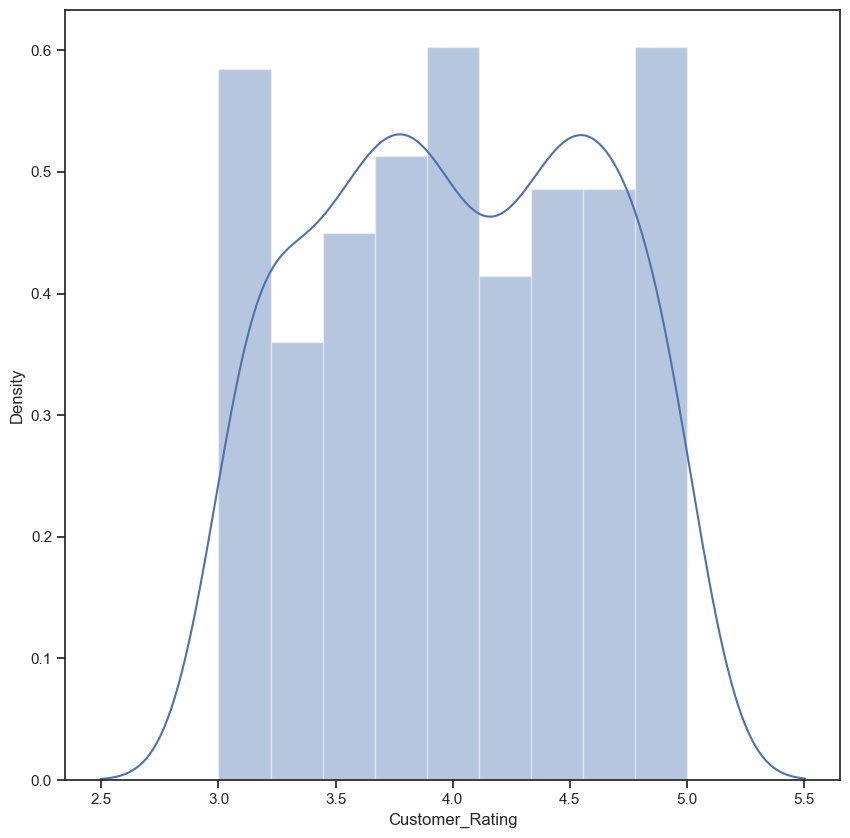

In [13]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.distplot(data['Customer_Rating'])

### Jointplot

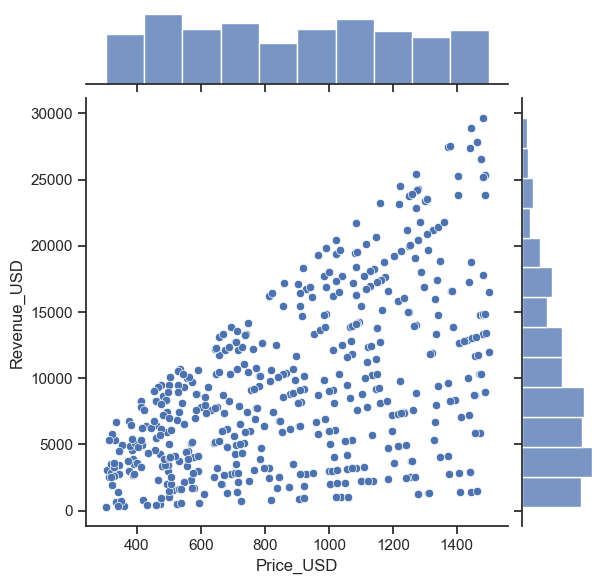

In [14]:
sns.jointplot(x='Price_USD', y='Revenue_USD', data=data)

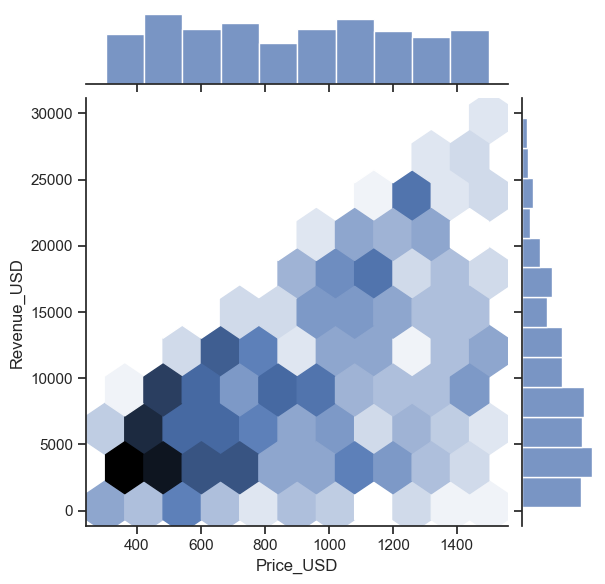

In [15]:
sns.jointplot(x='Price_USD', y='Revenue_USD', data=data, kind="hex")

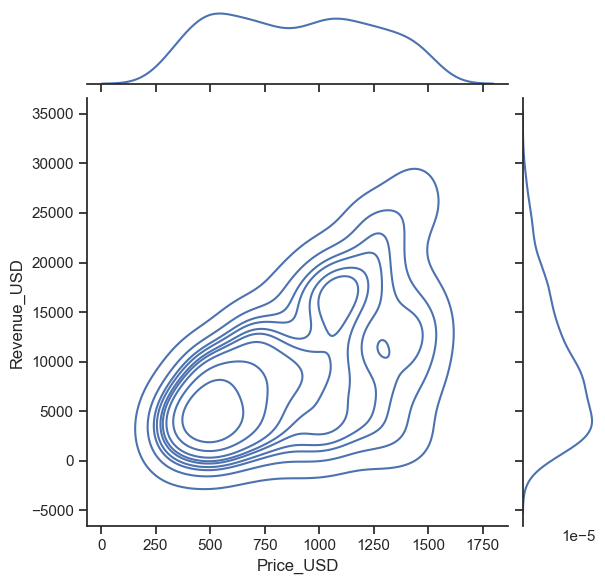

In [16]:
sns.jointplot(x='Price_USD', y='Revenue_USD', data=data, kind="kde")

### "Парные диаграммы"

Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответстуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

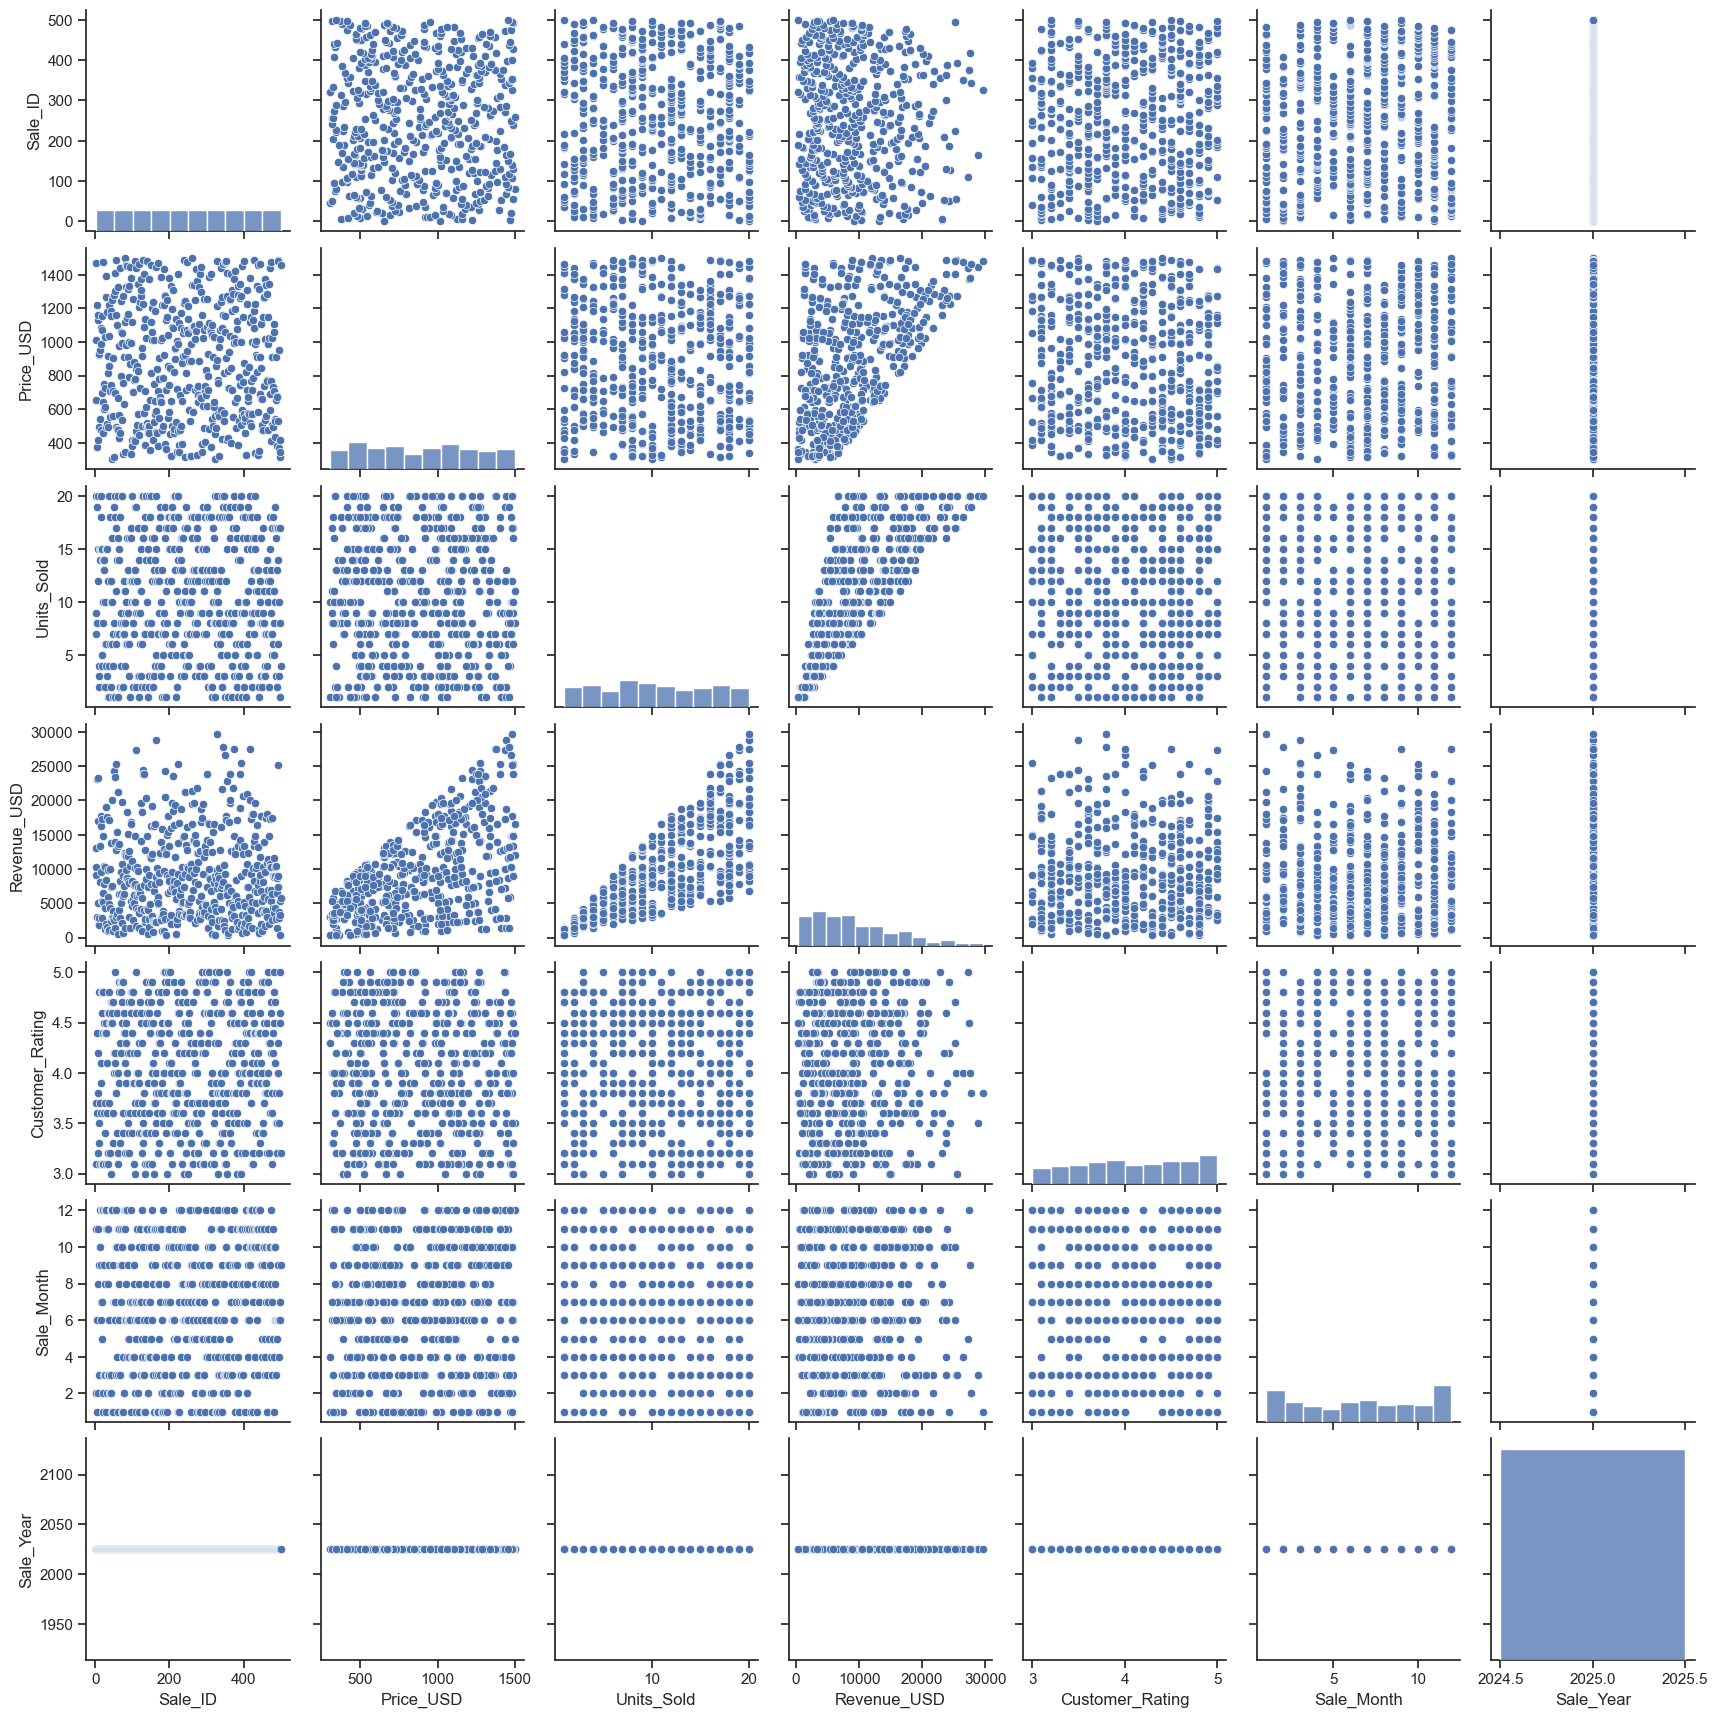

In [17]:
sns.pairplot(data)

С помощью параметра "hue" возможна группировка по значениям какого-либо признака.

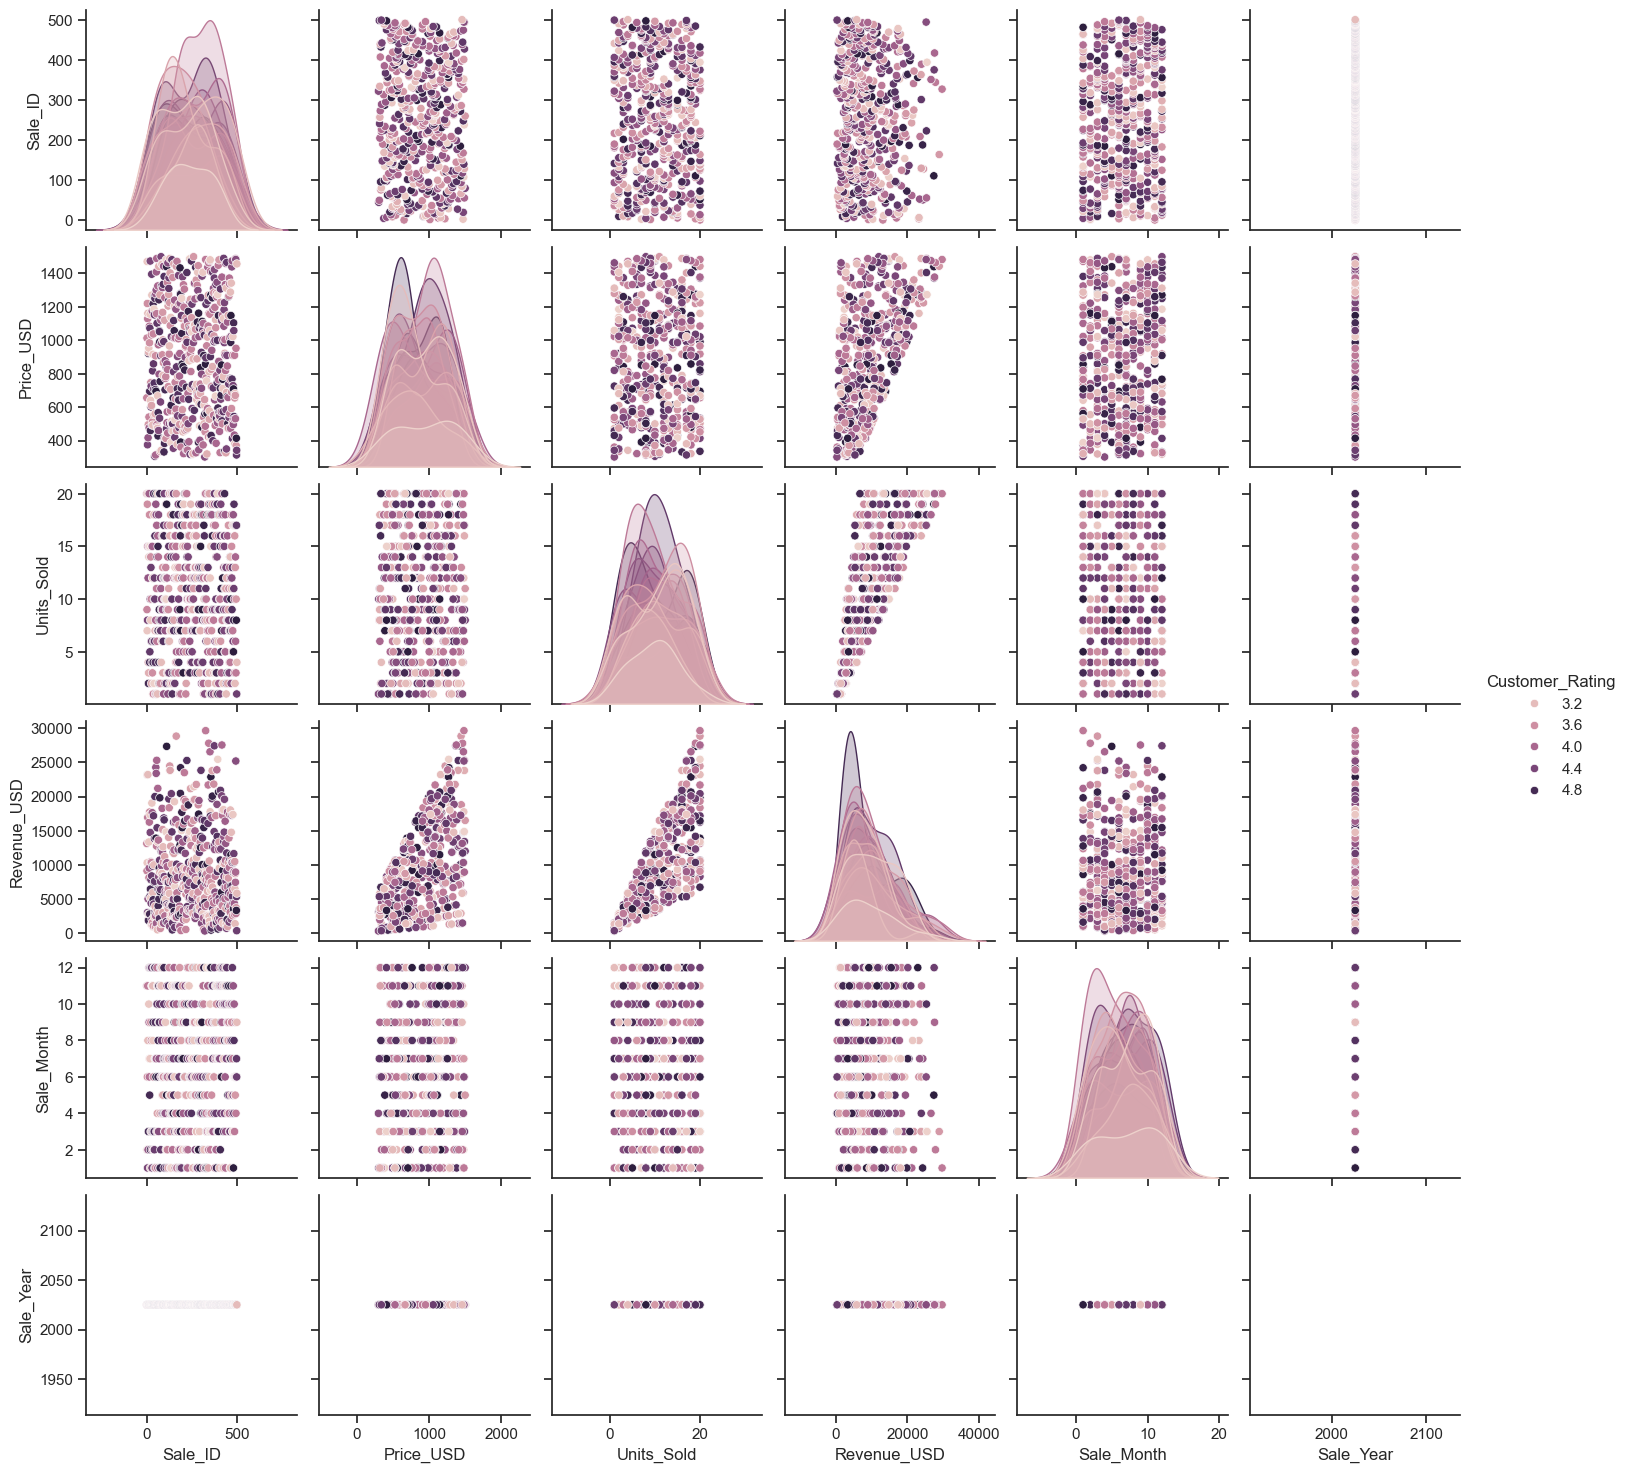

In [18]:
sns.pairplot(data, hue="Customer_Rating")

### Ящик с усами
Отображает одномерное распределение вероятности.

<Axes: xlabel='Customer_Rating'>

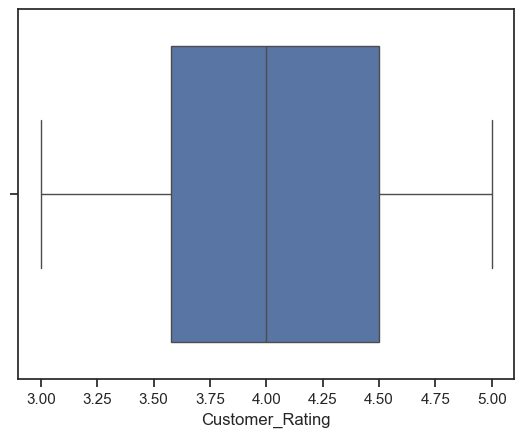

In [19]:
sns.boxplot(x=data['Customer_Rating'])

<Axes: ylabel='Customer_Rating'>

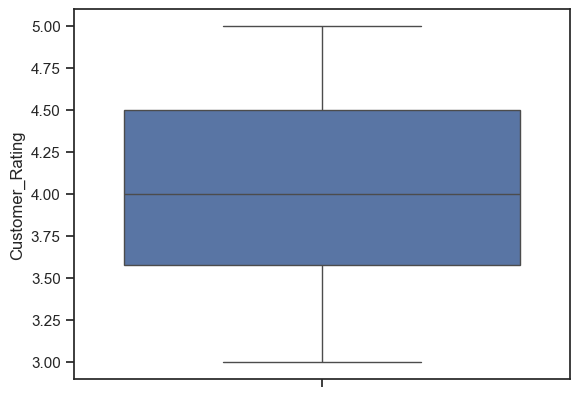

In [20]:
# По вертикали
sns.boxplot(y=data['Customer_Rating'])

<Axes: xlabel='Payment_Method', ylabel='Customer_Rating'>

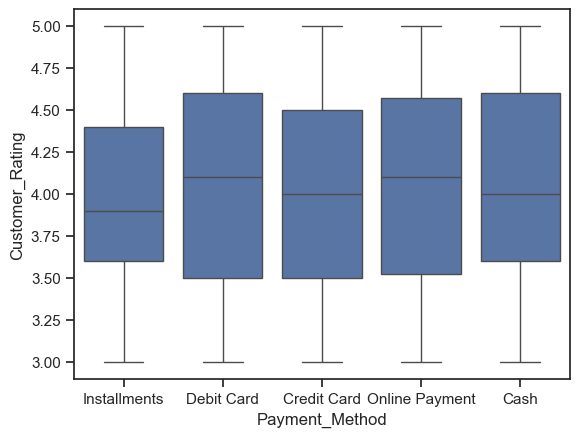

In [22]:
# Распределение параметра Payment_Method сгруппированные по Customer_Rating.
sns.boxplot(x='Payment_Method', y='Customer_Rating', data=data)

### Violin plot

<Axes: xlabel='Customer_Rating'>

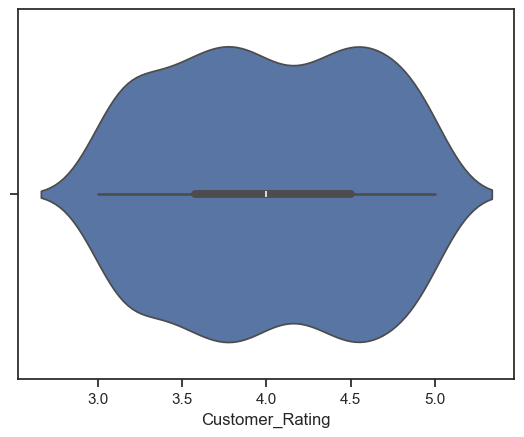

In [23]:
sns.violinplot(x=data['Customer_Rating'])

C:\Users\zagid\AppData\Local\Temp\ipykernel_26496\1193551885.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Customer_Rating'], ax=ax[1])


<Axes: xlabel='Customer_Rating', ylabel='Density'>

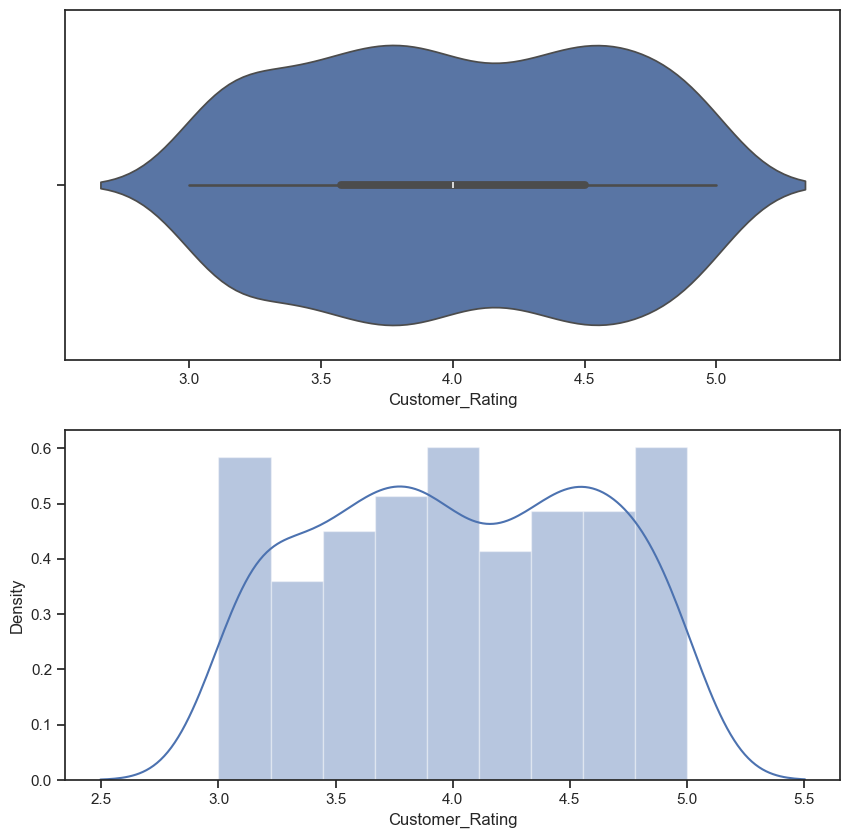

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Customer_Rating'])
sns.distplot(data['Customer_Rating'], ax=ax[1])

<Axes: xlabel='Payment_Method', ylabel='Customer_Rating'>

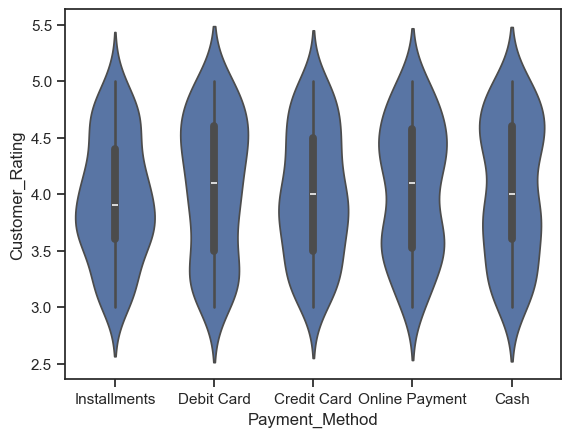

In [25]:
# Распределение параметра Customer_Rating сгруппированные по Payment_Method.
sns.violinplot(x='Payment_Method', y='Customer_Rating', data=data)

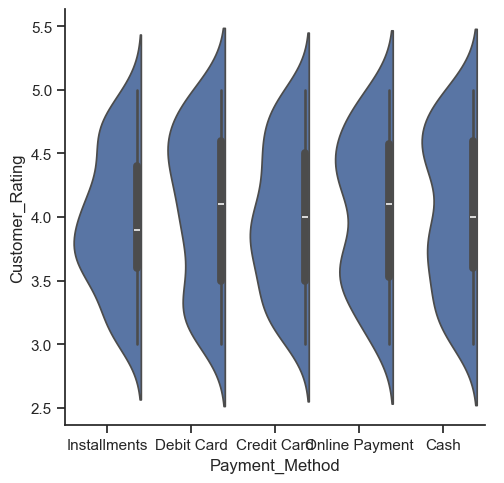

In [26]:
sns.catplot(y='Customer_Rating', x='Payment_Method', data=data, kind="violin", split=True)

### 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:

1. Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "Occupancy"). Именно эти признаки будут наиболее информативными для моделей машинного обучения. Признаки, которые слабо коррелируют с целевым признаком, можно попробовать исключить из построения модели, иногда это повышает качество модели. Нужно отметить, что некоторые алгоритмы машинного обучения автоматически определяют ценность того или иного признака для построения модели.
2. Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

In [28]:
data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr()


,Price_USD,Units_Sold,Revenue_USD,Customer_Rating
Price_USD,1.000000,-0.013772,0.544416,-0.019040
Units_Sold,-0.013772,1.000000,0.775950,0.011466
Revenue_USD,0.544416,0.775950,1.000000,0.015637
Customer_Rating,-0.019040,0.011466,0.015637,1.000000


Корреляционная матрица содержит коэффициенты корреляции между всеми парами признаков.

На основе корреляционной матрицы можно сделать следующие выводы:

- Целевой признак Customer_Rating практически не коррелирует ни с одним из 
  признаков: корреляция с Price_USD (-0.02), Units_Sold (0.01) и Revenue_USD (0.02) 
  близка к нулю. Это подтверждает выводы из диаграмм рассеяния.

- Наиболее сильная корреляция наблюдается между Price_USD и Revenue_USD (0.54) — 
  чем выше цена телефона, тем выше выручка. Это логично и ожидаемо.

- Также Units_Sold и Revenue_USD коррелируют между собой (0.78) — 
  выручка растёт с увеличением количества проданных единиц.

- Price_USD и Units_Sold практически не связаны (-0.01) — 
  цена телефона не влияет на количество продаж.

In [30]:
data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='pearson')

,Price_USD,Units_Sold,Revenue_USD,Customer_Rating
Price_USD,1.000000,-0.013772,0.544416,-0.019040
Units_Sold,-0.013772,1.000000,0.775950,0.011466
Revenue_USD,0.544416,0.775950,1.000000,0.015637
Customer_Rating,-0.019040,0.011466,0.015637,1.000000


In [33]:
!pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 3.4 MB/s eta 0:00:11
   - -------------------------------------- 1.6/37.3 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.4/37.3 MB 3.9 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/37.3 MB 4.1 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/37.3 MB 4.1 MB/s eta 0:00:08
   ----- ---------------------------------- 5.0/37.3 MB 4.1 MB/s eta 0:00:08
   ------ --------------------------------- 5.8/37.3 MB 4.0 MB/s eta 0:00:08
   ------- -------------------------------- 6.6/37.3 MB 3.9 MB/s eta 0:00:08
   ------- -------------------------------- 6.6/37.3 MB 3.9 MB/s eta 0:00:08
   ------- -------------------------------- 6.8/37.3 MB 3.5 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/37.3 MB 3.2 MB/s eta 0:00:10
   -------- ------------------------------- 7.9/37.3 MB 3.1 MB/s eta 0:00:10
   ---

In [34]:
data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='kendall')

,Price_USD,Units_Sold,Revenue_USD,Customer_Rating
Price_USD,1.000000,-0.010083,0.364934,-0.012134
Units_Sold,-0.010083,1.000000,0.641954,0.007912
Revenue_USD,0.364934,0.641954,1.000000,0.012836
Customer_Rating,-0.012134,0.007912,0.012836,1.000000


In [35]:
data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='spearman')

,Price_USD,Units_Sold,Revenue_USD,Customer_Rating
Price_USD,1.000000,-0.015479,0.514506,-0.017827
Units_Sold,-0.015479,1.000000,0.815090,0.010458
Revenue_USD,0.514506,0.815090,1.000000,0.020496
Customer_Rating,-0.017827,0.010458,0.020496,1.000000


<Axes: >

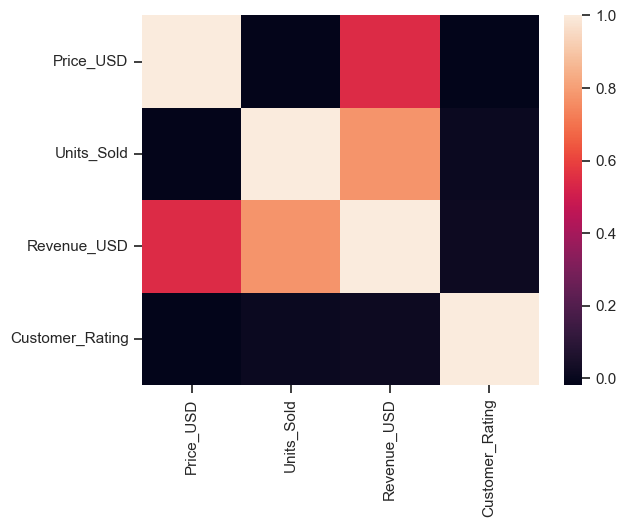

In [37]:
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr())

<Axes: >

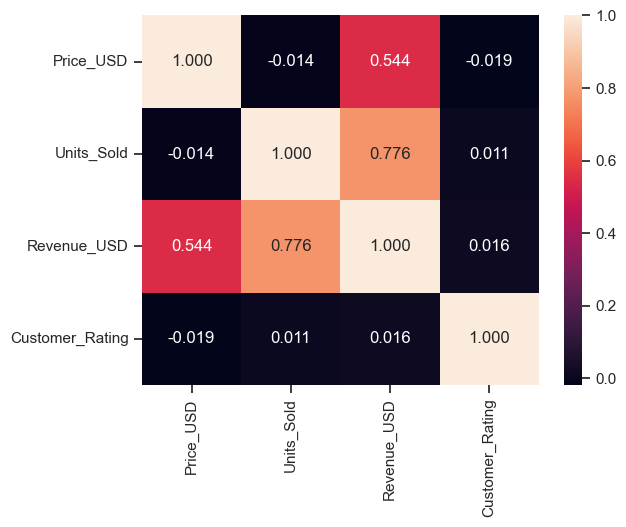

In [38]:
# Вывод значений в ячейках
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(), annot=True, fmt='.3f')

<Axes: >

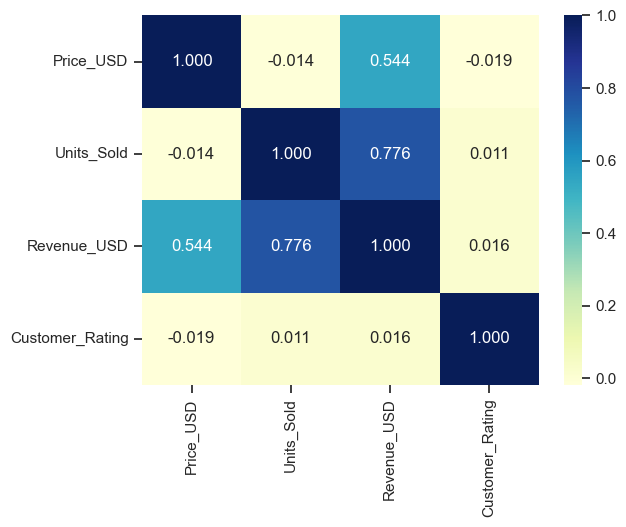

In [39]:
# Изменение цветовой гаммы
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(), cmap='YlGnBu', annot=True, fmt='.3f')

<Axes: >

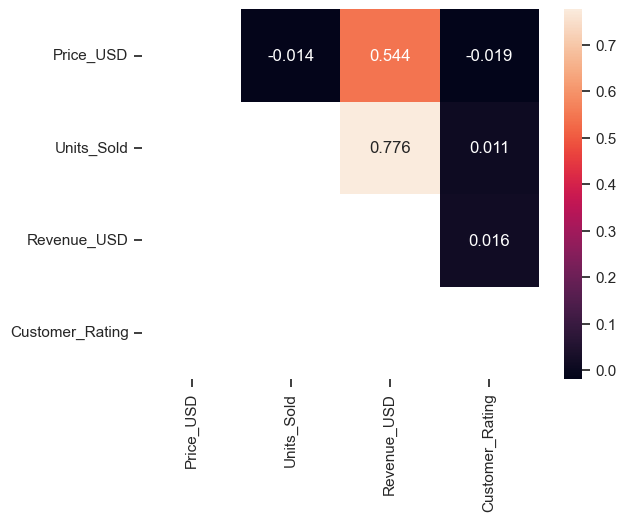

In [40]:
# Треугольный вариант матрицы
mask = np.zeros_like(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(), mask=mask, annot=True, fmt='.3f')

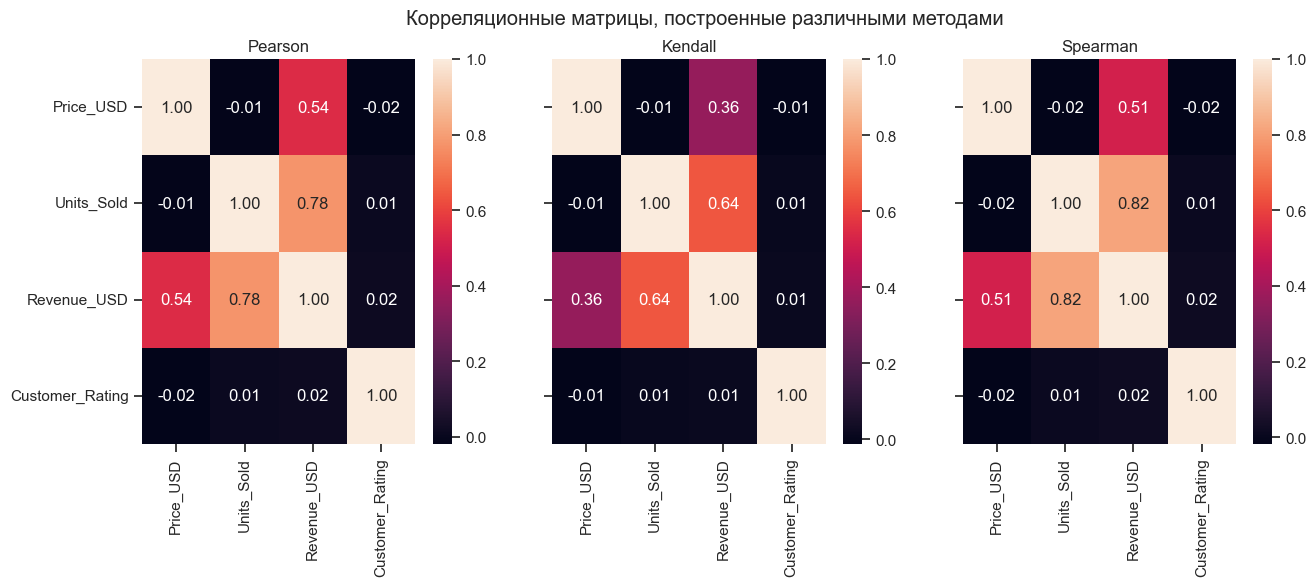

In [41]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='pearson'), ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='kendall'), ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(method='spearman'), ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

### Тепловая карта с указанием размера

<Axes: >

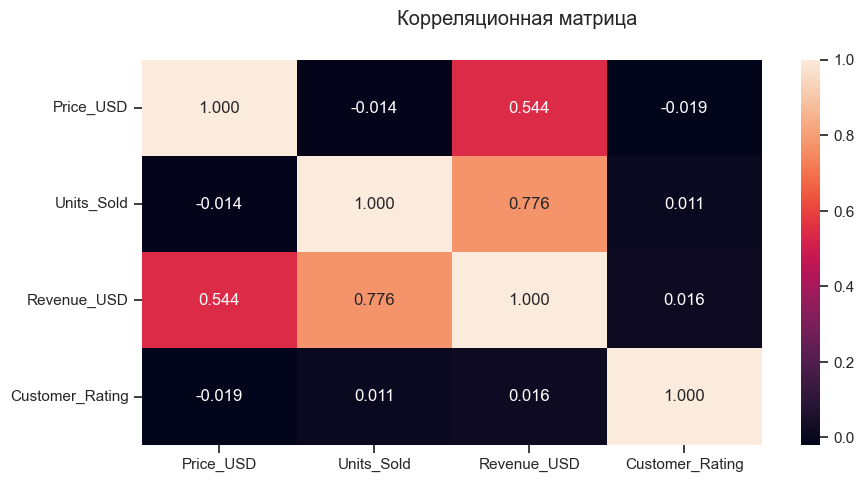

In [42]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Корреляционная матрица')
sns.heatmap(data[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Customer_Rating']].corr(), ax=ax, annot=True, fmt='.3f')

Тепловая карта позволяет наглядно увидеть корреляции между признаками.

Из анализа корреляционной матрицы можно сделать следующие выводы:

- Целевой признак Customer_Rating практически не коррелирует ни с одним 
  из признаков, что говорит о том, что рейтинг покупателя не зависит 
  от цены, количества продаж или выручки.

- Признаки Price_USD и Revenue_USD имеют умеренную корреляцию (0.54), 
  а Units_Sold и Revenue_USD — сильную корреляцию (0.78). Это означает, 
  что выручка определяется как ценой, так и количеством продаж.

- Поскольку Price_USD и Units_Sold оба коррелируют с Revenue_USD, 
  при построении модели стоит учитывать возможную мультиколлинеарность 
  и оставить только один из этих признаков, либо использовать оба 
  с осторожностью.